In [1]:
from google.colab import files
uploaded = files.upload()

Saving risk_factors_cervical_cancer.csv to risk_factors_cervical_cancer.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib .pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, accuracy_score, mean_squared_error

df = pd.read_csv("risk_factors_cervical_cancer.csv")
df.head()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
2,34,1.0,?,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,?,?,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,?,?,0,0,0,0,0,0,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Age                                 858 non-null    int64 
 1   Number of sexual partners           858 non-null    object
 2   First sexual intercourse            858 non-null    object
 3   Num of pregnancies                  858 non-null    object
 4   Smokes                              858 non-null    object
 5   Smokes (years)                      858 non-null    object
 6   Smokes (packs/year)                 858 non-null    object
 7   Hormonal Contraceptives             858 non-null    object
 8   Hormonal Contraceptives (years)     858 non-null    object
 9   IUD                                 858 non-null    object
 10  IUD (years)                         858 non-null    object
 11  STDs                                858 non-null    object

In [4]:
df.isnull().sum()

,0
Age,0
Number of sexual partners,0
First sexual intercourse,0
Num of pregnancies,0
Smokes,0
Smokes (years),0
Smokes (packs/year),0
Hormonal Contraceptives,0
Hormonal Contraceptives (years),0
IUD,0


In [5]:
df.shape

(858, 36)

In [6]:
df=df.replace("?",np.nan)
df = df.apply(pd.to_numeric)

In [7]:
df = df.fillna(df.median())

In [8]:
df.isnull().sum()

,0
Age,0
Number of sexual partners,0
First sexual intercourse,0
Num of pregnancies,0
Smokes,0
Smokes (years),0
Smokes (packs/year),0
Hormonal Contraceptives,0
Hormonal Contraceptives (years),0
IUD,0


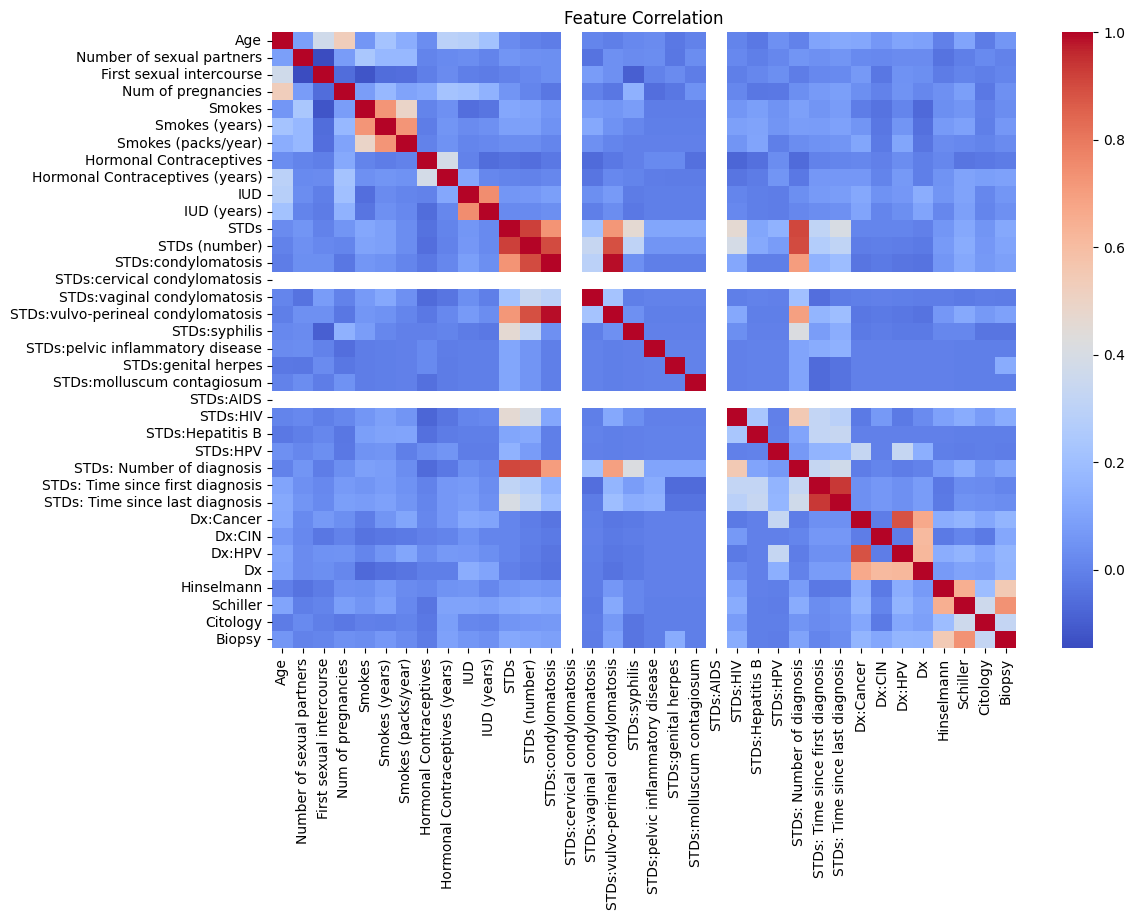

In [9]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

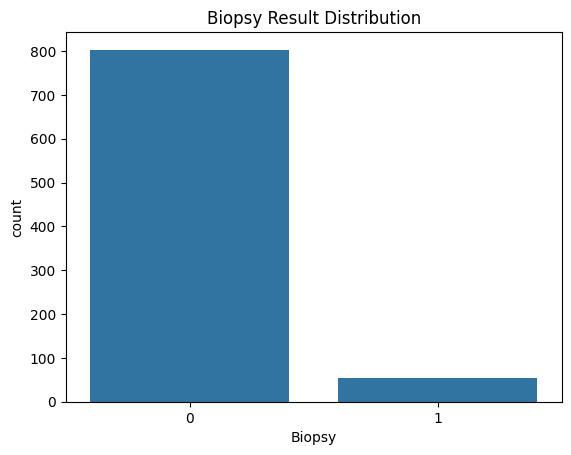

In [10]:
sns.countplot(x=df["Biopsy"])
plt.title("Biopsy Result Distribution")
plt.show()

In [11]:
X = df.drop("Biopsy", axis=1)
y = df["Biopsy"]

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Logistic Regression Model
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

from sklearn.metrics import accuracy_score

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))

# Decision Tree Model
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor()

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

from sklearn.metrics import r2_score

print("Decision Tree R2 Score:", r2_score(y_test, y_pred_tree))

# Random Forest Model
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest R2 Score:", r2_score(y_test, y_pred_rf))

Logistic Regression Accuracy: 0.9418604651162791
Decision Tree R2 Score: 0.12591756070016913
Random Forest R2 Score: 0.36661072840203257


In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [14]:
tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [15]:
print("Decision Tree Accuracy:", accuracy_score(y_test, tree.predict(X_test)))
print("Random Forest Accuracy:", accuracy_score(y_test, rf.predict(X_test)))

Decision Tree Accuracy: 0.9593023255813954
Random Forest Accuracy: 0.9244186046511628


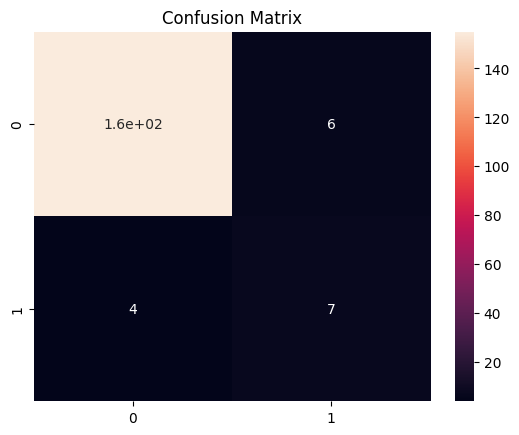

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True)
plt.title("Confusion Matrix")
plt.show()

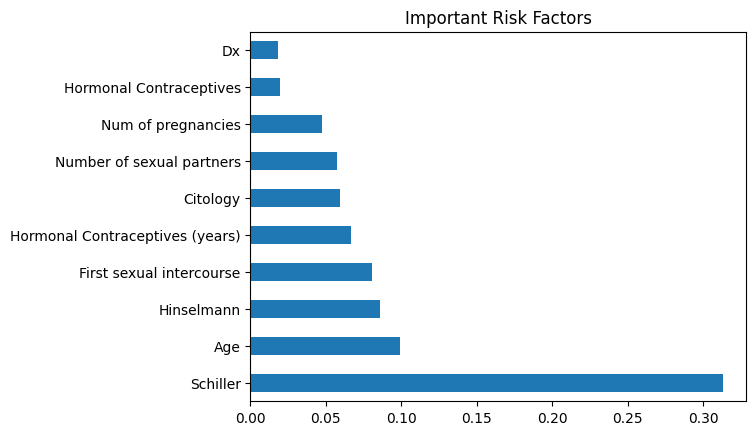

In [17]:
importance = rf.feature_importances_

features = pd.Series(importance, index=X.columns)

features.nlargest(10).plot(kind="barh")
plt.title("Important Risk Factors")
plt.show()

In [18]:
import joblib

joblib.dump(rf, "cervical_cancer_model.pkl")

['cervical_cancer_model.pkl']

In [19]:
sample = X_test[0].reshape(1,-1)

prediction = rf.predict(sample)

print("Prediction:", prediction)

Prediction: [0]


In [20]:
new_patient = np.array([[30,1,2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]])

In [21]:
prediction = rf.predict(new_patient)

print("Prediction:", prediction)

Prediction: [0]


In [22]:
if prediction[0] == 1:
    print("High Risk")
else:
    print("Low Risk")

Low Risk


In [23]:


new_patient = np.array([[45,1,6,16,5,10,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,1,1,1]])

new_patient = scaler.transform(new_patient)

prediction = rf.predict(new_patient)

print("Prediction:", prediction)

Prediction: [1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [24]:
if prediction[0] == 1:
    print("High Risk")
else:
    print("Low Risk")

High Risk


In [25]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = rf.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred.round()))

print("\nClassification Report:")
print(classification_report(y_test, y_pred.round()))

Confusion Matrix:
[[156   5]
 [  8   3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       161
           1       0.38      0.27      0.32        11

    accuracy                           0.92       172
   macro avg       0.66      0.62      0.64       172
weighted avg       0.91      0.92      0.92       172



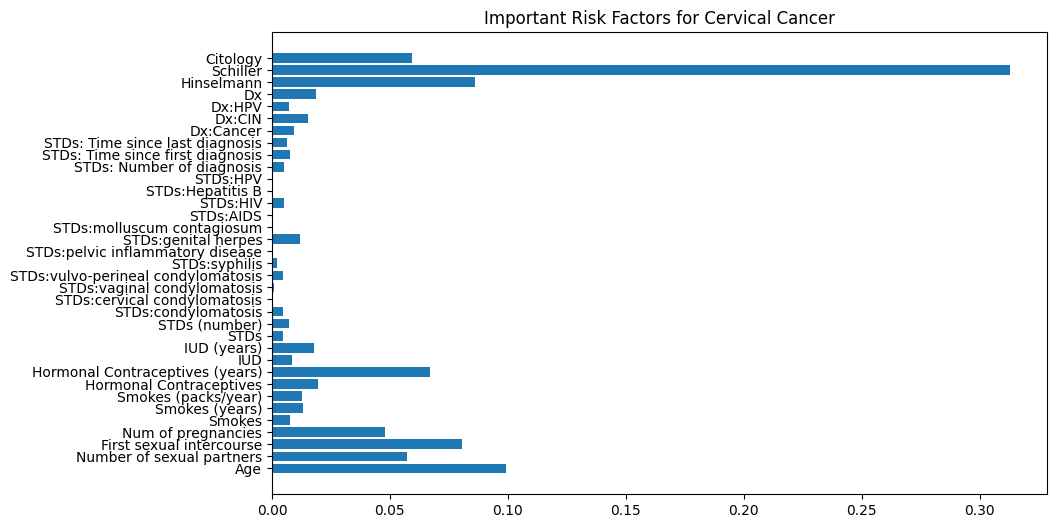

In [26]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
plt.barh(features, importances)
plt.title("Important Risk Factors for Cervical Cancer")
plt.show()

In [27]:
import joblib

joblib.dump(rf, "cervical_cancer_model.pkl")

['cervical_cancer_model.pkl']

In [28]:
model = joblib.load("cervical_cancer_model.pkl")

In [29]:


importance = rf.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

print(importance_df.head(10))

                            Feature  Importance
33                         Schiller    0.312884
0                               Age    0.099284
32                       Hinselmann    0.086142
2          First sexual intercourse    0.080446
8   Hormonal Contraceptives (years)    0.066928
34                         Citology    0.059512
1         Number of sexual partners    0.057073
3                Num of pregnancies    0.047736
7           Hormonal Contraceptives    0.019562
31                               Dx    0.018582


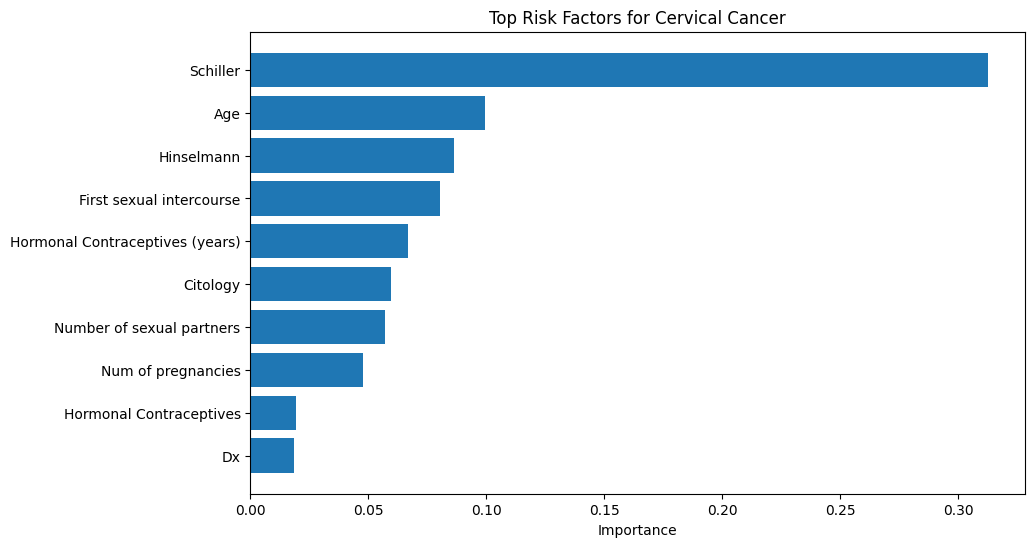

In [30]:
plt.figure(figsize=(10,6))
plt.barh(importance_df["Feature"][:10], importance_df["Importance"][:10])
plt.xlabel("Importance")
plt.title("Top Risk Factors for Cervical Cancer")
plt.gca().invert_yaxis()
plt.show()